# Predicting Loan Default the Way a Credit Team Actually Does It
### Real UCI credit data, imbalance-aware metrics, a cost-based decision, and explainability

Most "credit default" notebooks report accuracy on a balanced split and stop. That is not how lending works. This project models real default risk the way a credit team has to: the target is **imbalanced**, the wrong decision **costs money asymmetrically**, the model has to be **explainable**, and demographic attributes are **excluded for fair-lending reasons**.

**Data:** the UCI *Default of Credit Card Clients* dataset (30,000 real Taiwanese credit-card customers, 2005), with six months of repayment, billing and payment history and a real next-month default label.

**Headline results (test set):**
- XGBoost **ROC-AUC 0.78**, **PR-AUC 0.56** (no-skill PR-AUC is just the 0.22 default rate).
- A **cost-based threshold** turns the score into a business decision: at a 10:1 cost of a missed default vs a wrongly-declined customer, the model catches **92% of defaulters**.
- **Risk-based approval** cuts the default rate among approved customers from **22% to under 10%**.
- The model's risk drivers (via SHAP) are exactly what a credit analyst would expect: recent delinquency first, then utilisation and credit limit.


## Why these choices (and not the usual ones)
- **Accuracy is the wrong metric.** 22% of customers default, so a model that approves everyone is "78% accurate" and useless. We optimise and report **PR-AUC and recall**, not accuracy.
- **The decision is a business trade-off, not 0.5.** A missed default costs far more than a declined good customer, so the right threshold is chosen by **expected cost**, and it moves with the cost ratio.
- **Fair lending:** demographic attributes (sex, age, marital status, education) are **deliberately excluded** from the model. A lender generally cannot make decisions on protected characteristics; we keep them out and would audit fairness separately.
- **Explainability is mandatory** in regulated credit, so we use **SHAP** to show *why* the model scores a customer as it does.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, classification_report)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
import shap, warnings; warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
RND = 42

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load, clean, and engineer credit-relevant features

In [2]:
df = pd.read_csv("data/credit_default_taiwan.csv").rename(
        columns={"default payment next month": "default", "PAY_0": "PAY_1"}).drop(columns=["ID"])
PAY  = [f"PAY_{i}" for i in [1,2,3,4,5,6]]
BILL = [f"BILL_AMT{i}" for i in range(1,7)]
PAYA = [f"PAY_AMT{i}"  for i in range(1,7)]
base_rate = df["default"].mean()

# credit-relevant engineered features
df["utilisation"]       = (df["BILL_AMT1"]/df["LIMIT_BAL"]).clip(-1,5)
df["avg_bill"]          = df[BILL].mean(axis=1)
df["avg_payment"]       = df[PAYA].mean(axis=1)
df["payment_ratio"]     = (df["avg_payment"]/(df["avg_bill"].abs()+1)).clip(0,2)
df["months_delinquent"] = (df[PAY]>0).sum(axis=1)
df["max_delinquency"]   = df[PAY].max(axis=1)
ENG = ["utilisation","avg_bill","avg_payment","payment_ratio","months_delinquent","max_delinquency"]

FEATURES = ["LIMIT_BAL"]+PAY+BILL+PAYA+ENG    # NB: no demographics (fair lending)
X, y = df[FEATURES], df["default"]
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.25,stratify=y,random_state=RND)
print(f"{len(df):,} clients | default rate {base_rate:.1%} | 'approve everyone' accuracy {1-base_rate:.1%}")

30,000 clients | default rate 22.1% | 'approve everyone' accuracy 77.9%


## 1. The target is imbalanced, and one feature dominates
Default rate by **most-recent repayment status** is the single clearest signal: customers who paid on time default ~13% of the time; those two months behind default ~70% of the time.

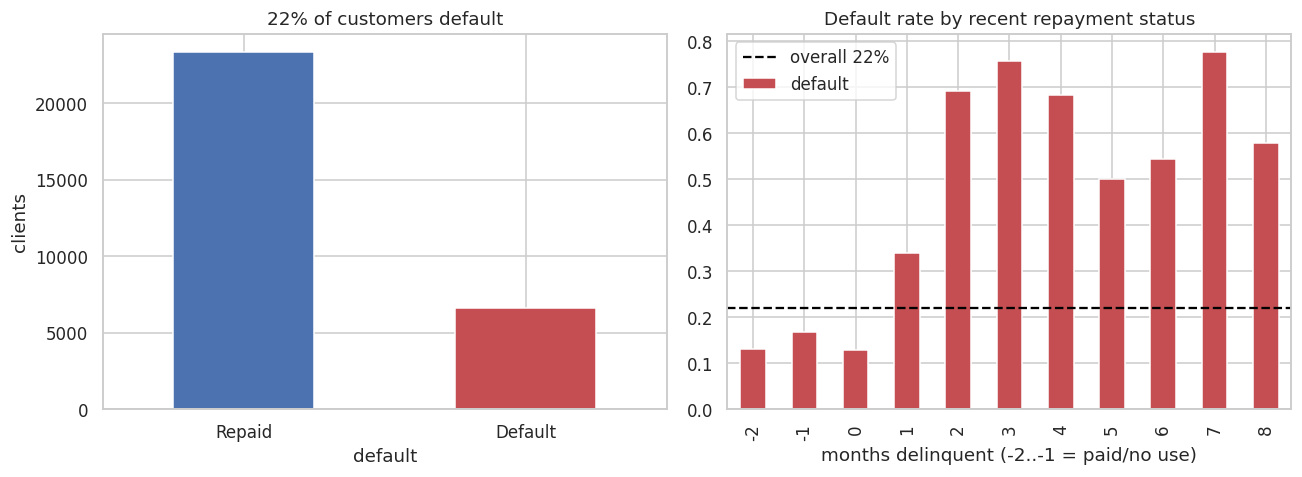

In [3]:
fig, ax = plt.subplots(1,2,figsize=(12,4.5))
df["default"].value_counts().sort_index().plot(kind="bar",ax=ax[0],color=["#4c72b0","#c44e52"])
ax[0].set_xticklabels(["Repaid","Default"],rotation=0); ax[0].set_title(f"{base_rate:.0%} of customers default"); ax[0].set_ylabel("clients")
r = df.groupby("PAY_1")["default"].mean(); r.plot(kind="bar",ax=ax[1],color="#c44e52")
ax[1].axhline(base_rate,ls="--",color="black",label=f"overall {base_rate:.0%}")
ax[1].set_title("Default rate by recent repayment status"); ax[1].set_xlabel("months delinquent (-2..-1 = paid/no use)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 2. Two models, judged on the right curves
A class-weighted **logistic regression** (interpretable baseline) and an imbalance-tuned **XGBoost**. The precision-recall curve is the one that matters here, because under 22% prevalence a random model's precision is only 0.22.

Logistic   ROC-AUC 0.748 | PR-AUC 0.500
XGBoost    ROC-AUC 0.775 | PR-AUC 0.558
no-skill   PR-AUC 0.221


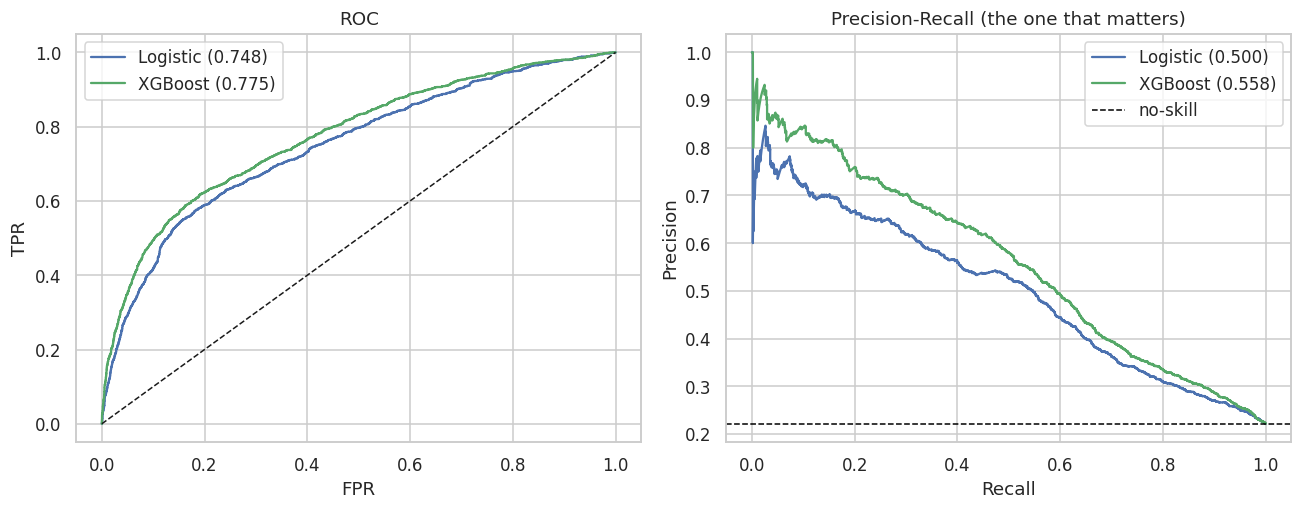

In [4]:
scaler = StandardScaler().fit(Xtr)
logit = LogisticRegression(max_iter=2000, class_weight="balanced").fit(scaler.transform(Xtr), ytr)
p_logit = logit.predict_proba(scaler.transform(Xte))[:,1]
spw = (ytr==0).sum()/(ytr==1).sum()
xgb = XGBClassifier(n_estimators=400,max_depth=4,learning_rate=0.05,subsample=0.9,colsample_bytree=0.8,
                    scale_pos_weight=spw,eval_metric="aucpr",random_state=RND,n_jobs=4).fit(Xtr,ytr)
p_xgb = xgb.predict_proba(Xte)[:,1]
for n,p in [("Logistic",p_logit),("XGBoost",p_xgb)]:
    print(f"{n:10s} ROC-AUC {roc_auc_score(yte,p):.3f} | PR-AUC {average_precision_score(yte,p):.3f}")
print(f"{'no-skill':10s} PR-AUC {base_rate:.3f}")

fig,ax=plt.subplots(1,2,figsize=(12,4.8))
for n,p,col in [("Logistic",p_logit,"#4c72b0"),("XGBoost",p_xgb,"#55a868")]:
    fpr,tpr,_=roc_curve(yte,p); ax[0].plot(fpr,tpr,c=col,label=f"{n} ({roc_auc_score(yte,p):.3f})")
    pr,rc,_=precision_recall_curve(yte,p); ax[1].plot(rc,pr,c=col,label=f"{n} ({average_precision_score(yte,p):.3f})")
ax[0].plot([0,1],[0,1],"k--",lw=1); ax[0].set_title("ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
ax[1].axhline(base_rate,ls="--",color="black",lw=1,label=f"no-skill"); ax[1].set_title("Precision-Recall (the one that matters)"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
plt.tight_layout(); plt.show()

## 3. From a score to a decision: cost-based thresholding
The model outputs a risk score; the **business** decides the threshold. A missed default (false negative) is far costlier than a wrongly-declined good customer (false positive). The cost-minimising threshold sits well below 0.5, and it moves with the cost ratio, this is where modelling meets commercial impact.

FN=2x FP -> threshold 0.65 | catches 51% of defaulters | approves 81%
FN=5x FP -> threshold 0.41 | catches 72% of defaulters | approves 59%
FN=10x FP -> threshold 0.22 | catches 92% of defaulters | approves 26%


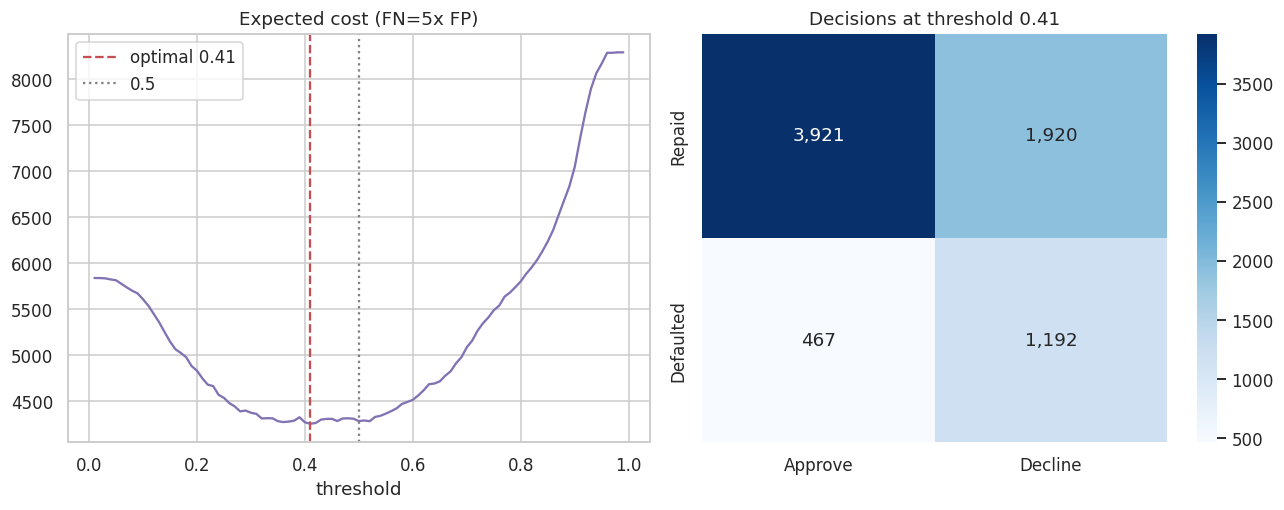

              precision    recall  f1-score   support

      Repaid      0.894     0.671     0.767      5841
     Default      0.383     0.719     0.500      1659

    accuracy                          0.682      7500
   macro avg      0.638     0.695     0.633      7500
weighted avg      0.781     0.682     0.708      7500



In [5]:
def opt_threshold(p, ratio):
    ths=np.linspace(0.01,0.99,99)
    costs=np.array([ratio*((p<t)&(yte==1)).sum()+((p>=t)&(yte==0)).sum() for t in ths])
    return ths[costs.argmin()], ths, costs
for r in [2,5,10]:
    t,_,_=opt_threshold(p_xgb,r); pred=(p_xgb>=t).astype(int)
    rec=((pred==1)&(yte==1)).sum()/(yte==1).sum()
    print(f"FN={r}x FP -> threshold {t:.2f} | catches {rec:.0%} of defaulters | approves {(pred==0).mean():.0%}")

RATIO=5; t_star,ths,costs=opt_threshold(p_xgb,RATIO)
fig,ax=plt.subplots(1,2,figsize=(12,4.8))
ax[0].plot(ths,costs,color="#8172b3"); ax[0].axvline(t_star,ls="--",color="#c44e52",label=f"optimal {t_star:.2f}"); ax[0].axvline(0.5,ls=":",color="grey",label="0.5")
ax[0].set_title(f"Expected cost (FN={RATIO}x FP)"); ax[0].set_xlabel("threshold"); ax[0].legend()
sns.heatmap(confusion_matrix(yte,(p_xgb>=t_star).astype(int)),annot=True,fmt=",d",cmap="Blues",ax=ax[1],
            xticklabels=["Approve","Decline"],yticklabels=["Repaid","Defaulted"])
ax[1].set_title(f"Decisions at threshold {t_star:.2f}"); plt.tight_layout(); plt.show()
print(classification_report(yte,(p_xgb>=t_star).astype(int),target_names=["Repaid","Default"],digits=3))

## 4. The commercial picture: risk-based approval
Approving the safest customers first, the default rate among the approved book falls sharply below the 22% population rate. This is the value of a credit model stated in business terms.

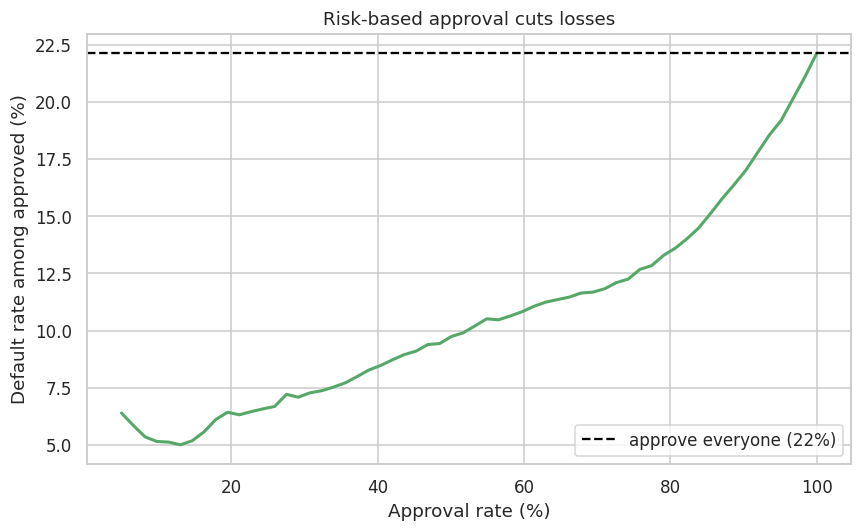

approve safest 50% -> default rate among approved 9.7%
approve safest 70% -> default rate among approved 11.8%
approve safest 90% -> default rate among approved 16.9%


In [6]:
order=np.argsort(p_xgb); y_ord=yte.values[order]
appr=np.linspace(0.05,1,60); bad=[y_ord[:max(1,int(a*len(y_ord)))].mean() for a in appr]
plt.figure(figsize=(8,5)); plt.plot(appr*100,np.array(bad)*100,color="#55a868",lw=2)
plt.axhline(base_rate*100,ls="--",color="black",label=f"approve everyone ({base_rate:.0%})")
plt.xlabel("Approval rate (%)"); plt.ylabel("Default rate among approved (%)"); plt.title("Risk-based approval cuts losses"); plt.legend(); plt.tight_layout(); plt.show()
for a in [0.5,0.7,0.9]: print(f"approve safest {a:.0%} -> default rate among approved {y_ord[:int(a*len(y_ord))].mean():.1%}")

## 5. Are the scores usable as probabilities? (calibration)
The model **ranks** risk well, but raw XGBoost scores (with class weighting) are not calibrated probabilities, the curve sits off the diagonal. In production you would calibrate (isotonic / Platt) before treating a score as a probability of default. Being explicit about this is what separates a usable score from a misleading one.

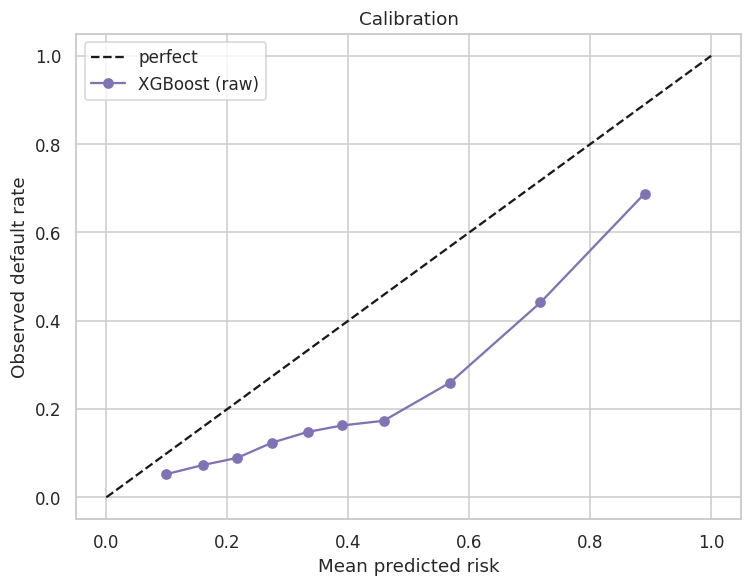

In [7]:
fp,mp=calibration_curve(yte,p_xgb,n_bins=10,strategy="quantile")
plt.figure(figsize=(7,5.5)); plt.plot([0,1],[0,1],"k--",label="perfect"); plt.plot(mp,fp,"o-",color="#8172b3",label="XGBoost (raw)")
plt.xlabel("Mean predicted risk"); plt.ylabel("Observed default rate"); plt.title("Calibration"); plt.legend(); plt.tight_layout(); plt.show()

## 6. Why the model decides what it decides (SHAP)
Regulated lending needs explainability. SHAP confirms the model learned credit-sensible logic: **recent and maximum delinquency** dominate, followed by **utilisation** and **credit limit**; larger payments push risk down.

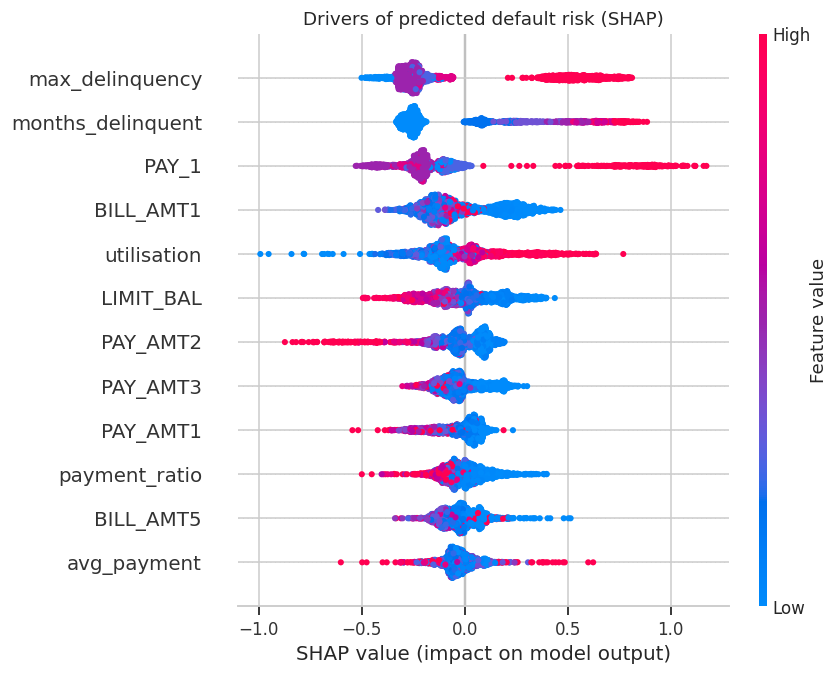

Top drivers:
max_delinquency      0.345
months_delinquent    0.292
PAY_1                0.264
BILL_AMT1            0.161
utilisation          0.151
LIMIT_BAL            0.132
PAY_AMT2             0.109
PAY_AMT3             0.089


In [8]:
expl=shap.TreeExplainer(xgb); samp=Xte.sample(2000,random_state=RND); sv=expl.shap_values(samp)
shap.summary_plot(sv,samp,show=False,max_display=12); plt.title("Drivers of predicted default risk (SHAP)"); plt.tight_layout(); plt.show()
imp=pd.Series(np.abs(sv).mean(0),index=samp.columns).sort_values(ascending=False)
print("Top drivers:"); print(imp.head(8).round(3).to_string())

## 7. How cleanly does the score separate good from bad?
Beyond a single AUC number, the two score distributions tell the story directly: defaulters pile up at high risk scores, repayers at low ones. The **Kolmogorov-Smirnov statistic** (the maximum gap between the two cumulative distributions, a standard credit-scoring measure) is **0.43**, which is solid separation for a behavioural model.

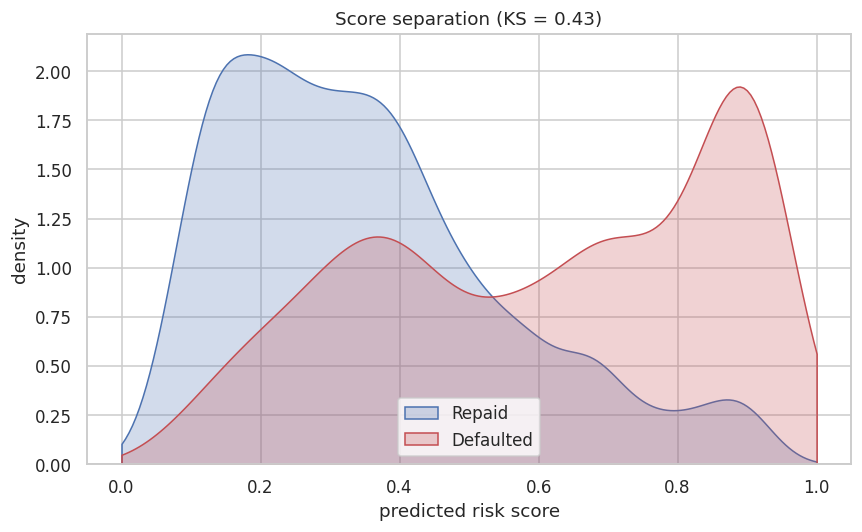

KS statistic = 0.427


In [9]:
from scipy.stats import ks_2samp
ks = ks_2samp(p_xgb[yte==1], p_xgb[yte==0]).statistic
plt.figure(figsize=(8,5))
sns.kdeplot(p_xgb[yte==0], fill=True, color="#4c72b0", label="Repaid", clip=(0,1))
sns.kdeplot(p_xgb[yte==1], fill=True, color="#c44e52", label="Defaulted", clip=(0,1))
plt.xlabel("predicted risk score"); plt.ylabel("density")
plt.title(f"Score separation (KS = {ks:.2f})"); plt.legend(); plt.tight_layout(); plt.show()
print(f"KS statistic = {ks:.3f}")

## 8. Explaining a single decision
Aggregate feature importance is not enough in lending: you have to justify one specific decision. SHAP does this per applicant. The customer below scored **97% risk**, and the reasons are legible, exactly what you would put in an adverse-action explanation: behind in all six months, two months behind last month, and repaying almost none of the balance.

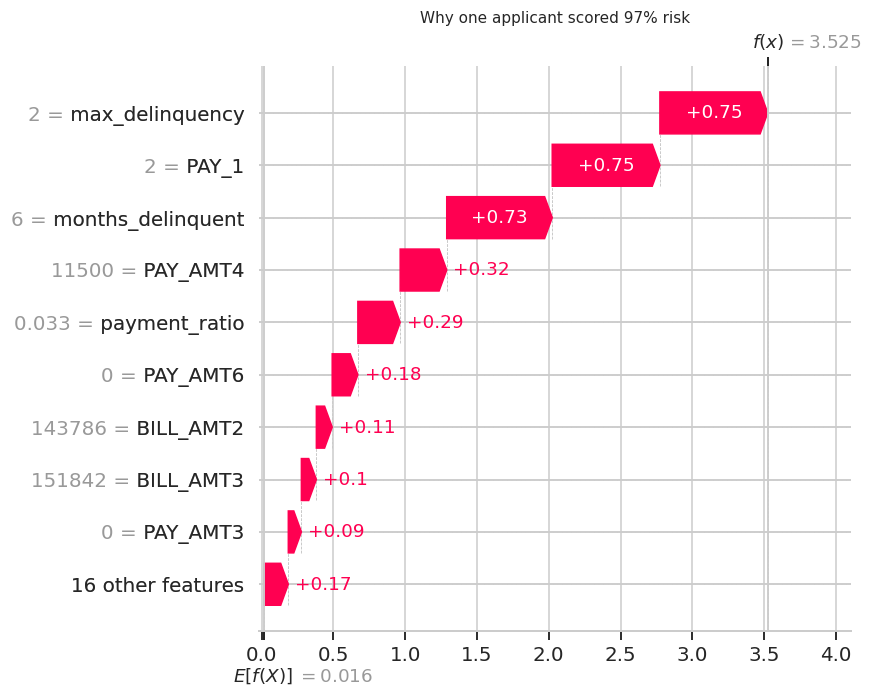

In [10]:
risk_samp = xgb.predict_proba(samp)[:,1]; idx = int(np.argmax(risk_samp))
ex = shap.Explanation(values=sv[idx], base_values=float(np.ravel(expl.expected_value)[0]),
                      data=samp.iloc[idx].values, feature_names=list(samp.columns))
shap.plots.waterfall(ex, max_display=10, show=False)
plt.title(f"Why one applicant scored {risk_samp[idx]:.0%} risk", fontsize=10); plt.tight_layout(); plt.show()

## Key findings
1. **The signal is delinquency.** Recent repayment status and the count/severity of missed months are by far the strongest predictors, ahead of any balance or limit feature.
2. **XGBoost beats a linear baseline and both beat no-skill** (PR-AUC 0.56 vs 0.50 vs 0.22).
3. **The decision threshold is a business lever.** Sweeping cost ratios moves the catch-rate from ~50% to ~92% of defaulters; there is no single "right" threshold without a cost view.
4. **Risk-based approval more than halves the default rate** among approved customers (22% to under 10%).

## Limitations
- **Behavioural features need history** (six months of repayments), so this scores existing customers better than thin-file new applicants, a real cold-start gap.
- **No income** in this dataset, so this is *behavioural* scoring, not affordability. (Affordability is the focus of a companion project.)
- **Raw scores need calibrating** before use as probabilities.
- **Fairness** was handled by exclusion; a production system would also audit outcomes across groups.

---
*Data: UCI Machine Learning Repository, "Default of Credit Card Clients". Built as a portfolio project.*